## Objective: Perform multiclass classification using logistic regression and evaluate the model(s).
#### Dataset: Iris (or you may substitute Digits).
#### Tools / libraries: Python, scikit-learn, pandas, matplotlib, (optional: GridSearchCV).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#### 1. Load dataset

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

#### 2. Split Data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)

#### 3. scale Data

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### 4. Train Logistic Regression models

In [5]:
multi_clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
multi_clf.fit(X_train, y_train)

LogisticRegression(max_iter=500, multi_class='multinomial')

In [6]:
ovr_clf = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=500)
ovr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=500, multi_class='ovr')

#### 5. Predictions

In [8]:
y_pred_multi = multi_clf.predict(X_test)
y_pred_ovr = ovr_clf.predict(X_test)

#### 6. Evaluations

In [10]:
print("=== Multinomial Logistic Regression ===")
print(classification_report(y_test, y_pred_multi, target_names=target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_multi))
print("Accuracy:", accuracy_score(y_test, y_pred_multi))

print("\n=== One-vs-Rest Logistic Regression ===")
print(classification_report(y_test, y_pred_ovr, target_names=target_names))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ovr))
print("Accuracy:", accuracy_score(y_test, y_pred_ovr))

=== Multinomial Logistic Regression ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.87        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Confusion Matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
Accuracy: 0.9111111111111111

=== One-vs-Rest Logistic Regression ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      0.73      0.76        15
   virginica       0.75      0.80      0.77        15

    accuracy                           0.84        45
   macro avg       0.85      0.84      0.84        45
weighted avg       0.85      0.84      0.84        45

Confusion Matrix:
 [[15  0  0]
 [ 0 11  4]
 [ 0  3 12]]
Accuracy: 0.8444

#### 7. Hyperparameter tuning

In [11]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500),
                    param_grid, cv=5)
grid.fit(X_train, y_train)
print("\nBest C from GridSearchCV:", grid.best_params_)



Best C from GridSearchCV: {'C': 1}


#### 8. Confusion matrix plot for Multinomial

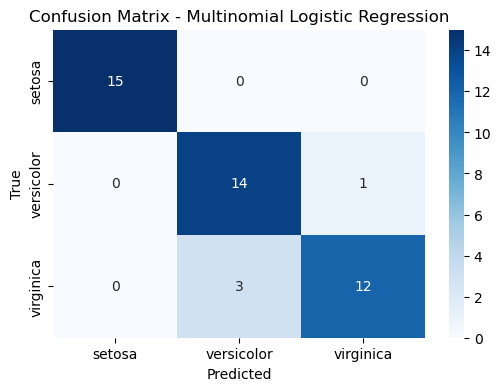

In [12]:
cm_multi = confusion_matrix(y_test, y_pred_multi)
plt.figure(figsize=(6,4))
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### 9. Confusion matrix plot for OvR

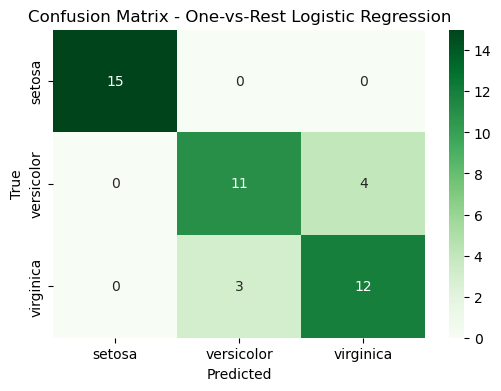

In [13]:
cm_ovr = confusion_matrix(y_test, y_pred_ovr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ovr, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - One-vs-Rest Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()